In [2]:
import matplotlib.pyplot as plt
%cd ..
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
%load_ext autoreload
%autoreload 2

/home/jafar/Arts/Parallel-Dynamic-Sparse-Training


/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/venv/lib/python3.12/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [126]:
import json
import glob
import pandas as pd 
import numpy as np
from collections import defaultdict
from benchmark.plots.matrix_matrix import *


def rename_colum(df, old_name, new_name):

    df["Type"] = df["Type"].apply(lambda x: x if x != old_name else new_name)



dense_level = "5200x5200"
df = pd.DataFrame()
for sparse_type in [
        "test_sparse_cupy",
        "test_sparse_cupy_csr",
        "test_sparse_torch_csr",
        "test_jax_bsr",
        "test_sparse_ut",
        "test_sparse_torch", 
        "test_dense",
]:
    
    dfc = pd.read_csv(f"/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/benchmark/log_mult_incl_cupy-{sparse_type}.csv")
    
        
    dfc["Type"] = dfc["isSparse"].apply(lambda x: sparse_type.replace("test_","")).copy()
    if sparse_type == "test_dense":
        dfc_temp = dfc[dfc["isSparse"] == "Dense"]
        dfc_temp["cuda_elapsed_time"] = dfc_temp["cuda_elapsed_time"] * 1.99
        dfc_temp["isSparse"] =dfc_temp["Type"] = "Dense+Mask"
        dfc = pd.concat([dfc, dfc_temp], axis=0)
        
    dfc["sparsity_level"] = dfc["sparsity_level"] * 100 / (dfc["sparsity_level"].max())
    df = pd.concat([df, dfc])
    # display(df.tail())
    if dense_level not in df['dense_level'].tolist():
        raise RuntimeError("Dense level is not in df")
display(df.tail())
rename_colum(df, "sparse_ut", "SpMM_COO(Snack)")
rename_colum(df, "Dense+Mask", "DenseMM+Mask")

rename_colum(df, "dense", "DenseMM")
rename_colum(df, "sparse_cupy", "SpMM_COO(Cupy)")
rename_colum(df, "sparse_torch", "SpMM_COO(Torch)")
rename_colum(df, "sparse_cupy_csr", "SpMM_CSR_(Cupy)")
rename_colum(df, "jax_bsr", "SpMM_CSR_(BSR)")
rename_colum(df, "sparse_torch_csr", "SpMM_CSR_(Torch)")

display(df.tail())

,isSparse,dense_level,sparsity_level,time,cuda_elapsed_time,rep,batch_size,Type
715,Dense+Mask,5200x5200,100.0,0.117222,233.231820,0,256,Dense+Mask
716,Dense+Mask,5200x5200,100.0,0.120264,239.298229,1,256,Dense+Mask
717,Dense+Mask,5200x5200,100.0,0.115795,230.395259,2,256,Dense+Mask
718,Dense+Mask,5200x5200,100.0,0.114648,228.117050,3,256,Dense+Mask
719,Dense+Mask,5200x5200,100.0,0.111559,221.969126,4,256,Dense+Mask


,isSparse,dense_level,sparsity_level,time,cuda_elapsed_time,rep,batch_size,Type
715,Dense+Mask,5200x5200,100.0,0.117222,233.231820,0,256,DenseMM+Mask
716,Dense+Mask,5200x5200,100.0,0.120264,239.298229,1,256,DenseMM+Mask
717,Dense+Mask,5200x5200,100.0,0.115795,230.395259,2,256,DenseMM+Mask
718,Dense+Mask,5200x5200,100.0,0.114648,228.117050,3,256,DenseMM+Mask
719,Dense+Mask,5200x5200,100.0,0.111559,221.969126,4,256,DenseMM+Mask


In [110]:
!pwd

/home/jafar/Arts/Parallel-Dynamic-Sparse-Training


/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/benchmark/plots/matrix_matrix.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/benchmark/plots/matrix_matrix.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  
/home/jafar/Arts/Parallel-Dynamic-Sparse-Training/benchmark/plots/matrix_matrix.py:161: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See t

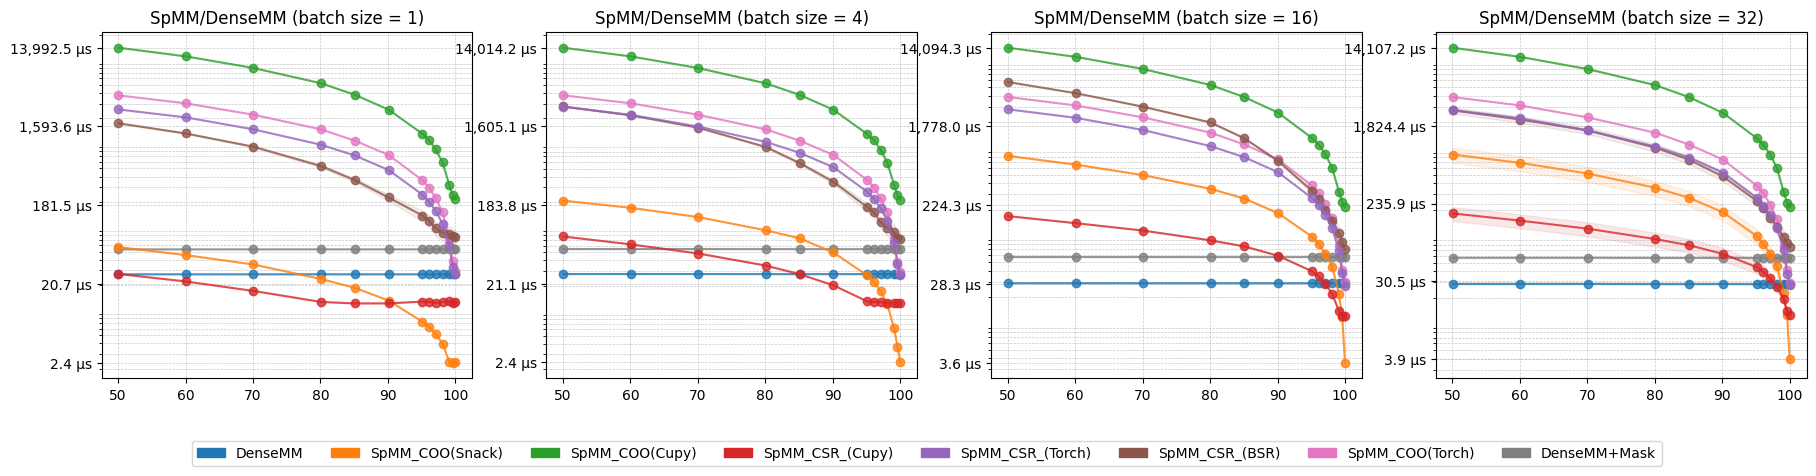

In [180]:


dfc = df[(df.sparsity_level >= 50) & (df.sparsity_level <= 100)]

fig = plt.figure(figsize=(22, 4.5))
axes = defaultdict(dict)
gs = fig.add_gridspec(1, 4) 
axes[0][2] = fig.add_subplot(gs[0, 0])
axes[1][2] = fig.add_subplot(gs[0, 1])
axes[0][3] = fig.add_subplot(gs[0, 2])
axes[1][3] = fig.add_subplot(gs[0, 3])
categories=[
        'DenseMM', 'SpMM_COO(Snack)', 'SpMM_COO(Cupy)' ,'SpMM_CSR_(Cupy)', 'SpMM_CSR_(Torch)', 'SpMM_CSR_(BSR)', 'SpMM_COO(Torch)', "DenseMM+Mask" 
    ]
_ = create_single_plot_for_batches(
    dfc, 
    dense_level, 
    "cuda_elapsed_time",
    [1],
    figsize=(7, 5), 
    log=True,
    title="SpMM/DenseMM (batch size = 1)",
    batch_needed=False,
    categories=categories,
    ax=axes[0][2]
)

_ = create_single_plot_for_batches(
    dfc, 
    dense_level, 
    "cuda_elapsed_time",
    [4],
    figsize=(7, 5), 
    log=True,
    title="SpMM/DenseMM (batch size = 4)",
    batch_needed=False,
    categories=categories,
    ax=axes[1][2]
)


_ = create_single_plot_for_batches(
    dfc, 
    dense_level, 
    "cuda_elapsed_time",
    [16],
    figsize=(7, 5), 
    log=True,
    title="SpMM/DenseMM (batch size = 16)",
    batch_needed=False,
       categories=categories,
    ax=axes[0][3]
)

_ = create_single_plot_for_batches(
    dfc, 
    dense_level, 
    "cuda_elapsed_time",
    [1, 32],
    figsize=(7, 5), 
    log=True,
    title="SpMM/DenseMM (batch size = 32)",
    batch_needed=False,
       categories=categories,
    ax=axes[1][3],
    legend_place="lower left",
)
for k in axes.keys():
    for v in axes[k].values():
        v.legend().set_visible(False)
legend_labels = categories
legend_colors = plt.cm.tab10.colors
from matplotlib.patches import Patch

# Create custom legend handles
custom_handles = [Patch(color=color, label=label) for color, label in zip(legend_colors, legend_labels)]
fig.legend(handles=custom_handles,
           ncol=8,
          loc='lower center',
           bbox_to_anchor=(0.5, -0.1),
           frameon=True)

# plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

fig.savefig("./figures/SpMM vs DenseMM.png", bbox_inches='tight')
plt.show()